In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv


In [2]:
import pandas as pd

# 读取训练数据
df = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv')

print("=== 数据基本信息 ===")
print(f"总行数: {df.shape[0]}, 总列数: {df.shape[1]}")
print(df.head(10))
print("\n=== 列名 ===")
print(df.columns.tolist())
print("\n=== 时间范围 ===")
print(f"开始: {df['date'].min()}")
print(f"结束: {df['date'].max()}")

=== 数据基本信息 ===
总行数: 3000888, 总列数: 6
   id        date  store_nbr        family  sales  onpromotion
0   0  2013-01-01          1    AUTOMOTIVE    0.0            0
1   1  2013-01-01          1     BABY CARE    0.0            0
2   2  2013-01-01          1        BEAUTY    0.0            0
3   3  2013-01-01          1     BEVERAGES    0.0            0
4   4  2013-01-01          1         BOOKS    0.0            0
5   5  2013-01-01          1  BREAD/BAKERY    0.0            0
6   6  2013-01-01          1   CELEBRATION    0.0            0
7   7  2013-01-01          1      CLEANING    0.0            0
8   8  2013-01-01          1         DAIRY    0.0            0
9   9  2013-01-01          1          DELI    0.0            0

=== 列名 ===
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

=== 时间范围 ===
开始: 2013-01-01
结束: 2017-08-15


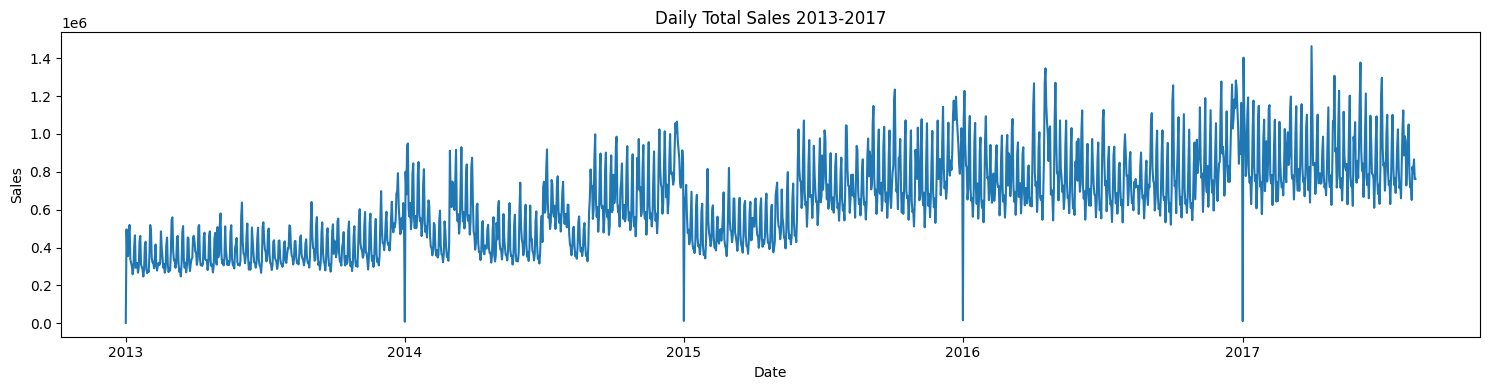


平均日销售额: 637556
最高日销售额: 1463084
最低日销售额: 2512


In [3]:
import matplotlib.pyplot as plt

# 按日期汇总总销售额
daily_sales = df.groupby('date')['sales'].sum().reset_index()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

plt.figure(figsize=(15,4))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Daily Total Sales 2013-2017')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

print(f"\n平均日销售额: {daily_sales['sales'].mean():.0f}")
print(f"最高日销售额: {daily_sales['sales'].max():.0f}")
print(f"最低日销售额: {daily_sales['sales'].min():.0f}")

MAE（平均绝对误差）: 339.55


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas

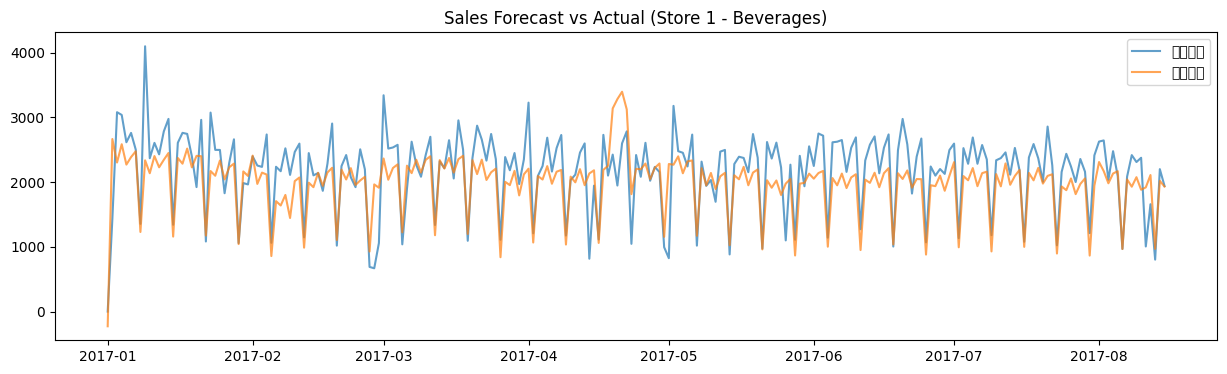

In [4]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# 只取1号门店的BEVERAGES类别，简化问题
mask = (df['store_nbr']==1) & (df['family']=='BEVERAGES')
store1 = df[mask].copy()
store1['date'] = pd.to_datetime(store1['date'])
store1 = store1.sort_values('date')

# 提取时间特征
store1['year'] = store1['date'].dt.year
store1['month'] = store1['date'].dt.month
store1['day'] = store1['date'].dt.day
store1['dayofweek'] = store1['date'].dt.dayofweek
store1['dayofyear'] = store1['date'].dt.dayofyear

# 训练/测试切分
train = store1[store1['date'] < '2017-01-01']
test = store1[store1['date'] >= '2017-01-01']

features = ['year','month','day','dayofweek','dayofyear','onpromotion']
X_train, y_train = train[features], train['sales']
X_test, y_test = test[features], test['sales']

# 训练模型
model = GradientBoostingRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 评估
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE（平均绝对误差）: {mae:.2f}")

# 画预测结果
plt.figure(figsize=(15,4))
plt.plot(test['date'].values, y_test.values, label='实际销售', alpha=0.7)
plt.plot(test['date'].values, y_pred, label='预测销售', alpha=0.7)
plt.title('Sales Forecast vs Actual (Store 1 - Beverages)')
plt.legend()
plt.show()

In [5]:
from openai import OpenAI

client = OpenAI(
    api_key="a340d621d3514dfb91bb9917428806ee.Zp1oJ2QDsjhEoDWo",
    base_url="https://open.bigmodel.cn/api/paas/v4/"
)

# 取最近7天预测结果
recent_pred = y_pred[-7:]
recent_actual = y_test.values[-7:]
avg_pred = recent_pred.mean()
max_pred = recent_pred.max()
min_pred = recent_pred.min()

def get_restock_advice(avg, max_val, min_val, mae):
    prompt = f"""
    You are a supply chain expert. Based on sales forecast data, give restocking advice in Chinese.
    
    Recent 7-day forecast for Store 1 Beverages:
    - Average daily sales forecast: {avg:.0f} units
    - Peak forecast: {max_val:.0f} units  
    - Lowest forecast: {min_val:.0f} units
    - Model error margin: {mae:.0f} units
    
    Please provide: 1.Recommended stock level 2.Restock timing 3.Risk warning
    Answer in Chinese, be concise and professional.
    """
    response = client.chat.completions.create(
        model="glm-4-flash",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

advice = get_restock_advice(avg_pred, max_pred, min_pred, mae)
print("=== AI备货建议 ===")
print(advice)

=== AI备货建议 ===
1. 推荐库存水平：根据平均日销量1844单位，建议库存水平为1844单位×7天=12888单位。考虑到峰值销售和最低销售，建议在库存水平基础上增加340单位的安全库存，即13228单位。

2. 补货时间：建议在库存降至13228单位的一半，即6614单位时进行补货。

3. 风险警告：需注意模型误差，实际销量可能超出预测范围。建议密切关注销售数据，根据实际情况调整库存策略。同时，关注市场动态，如季节性变化、促销活动等，及时调整补货计划。
